<a href="https://colab.research.google.com/github/au510621104021/FND_2027/blob/main/colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🔍 Multimodal Fake News Detection — Google Colab Training
**BERT + ViT + Cross-Modal Attention** framework for detecting fake news.

This notebook lets you train the full model on **Colab's free GPU (T4)**.

### Architecture
```
Text  →  BERT Encoder  →  projected text tokens  ─┐
                                                    ├→ Cross-Modal Attention → Gated Fusion → Classifier
Image →  ViT Encoder   →  projected image patches ─┘
```

### Key Features
- **Cross-Modal Attention** – Bidirectional text↔image attention
- **Gated Fusion** – Learned per-sample modality weighting
- **Focal Loss** – Handles class imbalance
- **Gradient Accumulation** – Larger effective batch sizes on T4
- **Mixed Precision (FP16)** – Memory-efficient training
- **Explainability** – Grad-CAM + attention visualization

In [2]:
# ============================================================
# STEP 1: Runtime Check & GPU Info
# ============================================================
import torch, os, sys, gc

USE_CUDA = torch.cuda.is_available()
DEVICE = 'cuda' if USE_CUDA else 'cpu'

print(f'PyTorch version: {torch.__version__}')
print(f'GPU: {torch.cuda.get_device_name(0) if USE_CUDA else "NOT AVAILABLE (CPU runtime)"}')
print(f'CUDA available: {USE_CUDA}')
print(f'Device: {DEVICE}')

if USE_CUDA:
    total_mem = torch.cuda.get_device_properties(0).total_memory / 1e9  # ✅ Fixed
    print(f'GPU Memory: {total_mem:.1f} GB')

PROJECT_DIR = '/content/fake_news_project'
os.makedirs(PROJECT_DIR, exist_ok=True)
print(f'\nProject dir: {PROJECT_DIR}')

PyTorch version: 2.10.0+cu128
GPU: Tesla T4
CUDA available: True
Device: cuda
GPU Memory: 15.6 GB

Project dir: /content/fake_news_project


In [3]:
# ============================================================
# STEP 2: Install Dependencies
# ============================================================
!pip -q install --upgrade pip
!pip -q install transformers>=4.30.0 datasets scikit-learn seaborn tqdm tensorboard pyyaml pandas Pillow matplotlib opencv-python-headless
print('\n✅ Dependencies installed')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 71.5 MB/s eta 0:00:00

✅ Dependencies installed


In [4]:
# ============================================================
# STEP 3: Clone Project from GitHub
# ============================================================
import os, shutil, subprocess

# ---- CONFIGURE YOUR REPO HERE ----
GITHUB_REPO = 'https://github.com/au510621104021/FFake_detection.git'
GITHUB_BRANCH = ''  # empty = default branch; or set e.g. 'main'

# Optional for private repos:
# from google.colab import userdata
# os.environ['GITHUB_TOKEN'] = userdata.get('GITHUB_TOKEN')
GITHUB_TOKEN = os.getenv('GITHUB_TOKEN', '').strip()

clone_url = GITHUB_REPO
if GITHUB_TOKEN and GITHUB_REPO.startswith('https://'):
    clone_url = GITHUB_REPO.replace('https://', f'https://{GITHUB_TOKEN}@', 1)

if os.path.exists(PROJECT_DIR):
    shutil.rmtree(PROJECT_DIR)

clone_cmd = ['git', 'clone', '--single-branch']
if GITHUB_BRANCH.strip():
    clone_cmd += ['--branch', GITHUB_BRANCH.strip()]
clone_cmd += [clone_url, PROJECT_DIR]

try:
    subprocess.check_call(clone_cmd)
except subprocess.CalledProcessError as e:
    print(f'❌ Clone failed: {e}')
    print('Make sure the repository URL is correct and accessible.')
    raise

# Remove token from local git config for safety
if clone_url != GITHUB_REPO:
    subprocess.check_call(['git', '-C', PROJECT_DIR, 'remote', 'set-url', 'origin', GITHUB_REPO])

commit = subprocess.check_output(['git', '-C', PROJECT_DIR, 'rev-parse', '--short', 'HEAD'], text=True).strip()
branch = subprocess.check_output(['git', '-C', PROJECT_DIR, 'rev-parse', '--abbrev-ref', 'HEAD'], text=True).strip()
print(f'\n✅ Cloned: {GITHUB_REPO}')
print(f'   Branch: {branch}')
print(f'   Commit: {commit}')



✅ Cloned: https://github.com/au510621104021/FFake_detection.git
   Branch: main
   Commit: 3279c70


In [5]:
# ============================================================
# STEP 3.1: Install Project Requirements (from cloned repo)
# ============================================================
import os, subprocess, sys

req_file = os.path.join(PROJECT_DIR, 'requirements.txt')
if not os.path.exists(req_file):
    raise FileNotFoundError(f'requirements.txt not found at {req_file}')

subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', '-r', req_file])
print('✅ Installed requirements from repo')


✅ Installed requirements from repo


In [6]:
# ============================================================
# STEP 4: Dataset Setup (ISOT or custom CSV)
# ============================================================
import os
from google.colab import files as gfiles

DATA_DIR = os.path.join(PROJECT_DIR, 'data', 'isot')
os.makedirs(DATA_DIR, exist_ok=True)

print(f'Data directory: {DATA_DIR}')
existing = sorted(os.listdir(DATA_DIR))
print('Existing files:', existing if existing else 'None')

need_upload = not (
    os.path.exists(os.path.join(DATA_DIR, 'Fake.csv'))
    and os.path.exists(os.path.join(DATA_DIR, 'True.csv'))
)

if need_upload:
    print('\n📤 Upload dataset files now.')
    print('   For ISOT: Fake.csv + True.csv')
    print('   For custom data: train.csv/test.csv or dataset.csv with text + label columns')
    up = gfiles.upload()

    for name, data in up.items():
        dest = os.path.join(DATA_DIR, name)
        with open(dest, 'wb') as f:
            f.write(data)
        print(f'  ✅ Saved: {dest} ({len(data)/1e6:.1f} MB)')

print('\nFinal files in data dir:', sorted(os.listdir(DATA_DIR)))


Data directory: /content/fake_news_project/data/isot
Existing files: None

📤 Upload dataset files now.
   For ISOT: Fake.csv + True.csv
   For custom data: train.csv/test.csv or dataset.csv with text + label columns


Saving test.csv to test.csv
Saving train.csv to train.csv
  ✅ Saved: /content/fake_news_project/data/isot/test.csv (15.3 MB)
  ✅ Saved: /content/fake_news_project/data/isot/train.csv (63.4 MB)

Final files in data dir: ['test.csv', 'train.csv']


In [7]:
# ============================================================
# STEP 5: Verify Project Structure & Patch Source Code
# ============================================================
import sys, os
sys.path.insert(0, PROJECT_DIR)
os.chdir(PROJECT_DIR)

# Quick structure check
required_paths = ['src', 'config/config.yaml', 'scripts/train.py']
missing = [p for p in required_paths if not os.path.exists(os.path.join(PROJECT_DIR, p))]
if missing:
    raise FileNotFoundError(f'Missing required project files: {missing}')

print('✅ Project looks valid. Root:', PROJECT_DIR)
for root, dirs, fls in os.walk(PROJECT_DIR):
    dirs[:] = [d for d in dirs if d not in {'__pycache__', '.git', '.venv', '.venv310', 'node_modules', '.dist'}]
    level = root.replace(PROJECT_DIR, '').count(os.sep)
    indent = '  ' * level
    print(f'{indent}{os.path.basename(root)}/')
    sub = '  ' * (level + 1)
    for f in fls[:8]:
        print(f'{sub}{f}')
    if level >= 2:
        continue


✅ Project looks valid. Root: /content/fake_news_project
fake_news_project/
  colab.ipynb
  .gitignore
  README.md
  requirements.txt
  app/
    streamlit_app.py
    web_app.py
  config/
    config.yaml
  src/
    __init__.py
    inference/
      predictor.py
      __init__.py
    training/
      trainer.py
      metrics.py
      __init__.py
    models/
      text_encoder.py
      cross_modal_attention.py
      image_encoder.py
      __init__.py
      multimodal_detector.py
    data/
      dataset.py
      preprocessing.py
      __init__.py
    explainability/
      grad_cam.py
      attention_viz.py
      __init__.py
  Fake or Real News Dataset/
    test.csv
    train.csv
  Fake News Dataset/
    test.csv
    train.csv
  data/
    isot/
      test.csv
      train.csv
  scripts/
    predict.py
    evaluate.py
    prepare_isot_dataset.py
    train.py
  Fake News Detection Dataset/
    test.csv
    train.csv
  ISOT Fake News Dataset/
    test.csv
    train.csv


In [8]:
# ============================================================
# STEP 5.1: Patch Trainer for Modern PyTorch AMP API
# ============================================================
# This fixes the deprecated torch.cuda.amp imports that cause
# warnings/errors on newer PyTorch versions in Colab.

trainer_path = os.path.join(PROJECT_DIR, 'src', 'training', 'trainer.py')

with open(trainer_path, 'r') as f:
    trainer_code = f.read()

# Fix 1: Replace deprecated torch.cuda.amp imports
old_import = 'from torch.cuda.amp import autocast, GradScaler'
new_import = '''# Modern PyTorch AMP API (compatible with PyTorch 2.x)
try:
    from torch.amp import autocast, GradScaler
    AMP_DEVICE_TYPE = 'cuda'
except ImportError:
    from torch.cuda.amp import autocast, GradScaler
    AMP_DEVICE_TYPE = None'''

if old_import in trainer_code:
    trainer_code = trainer_code.replace(old_import, new_import)
    print('✅ Patched AMP imports')

# Fix 2: Replace GradScaler() with GradScaler('cuda')
trainer_code = trainer_code.replace(
    "self.scaler = GradScaler() if self.train_cfg.get(\"fp16\", False) else None",
    "self.scaler = GradScaler('cuda') if self.train_cfg.get('fp16', False) and torch.cuda.is_available() else None"
)

# Fix 3: Replace autocast() with autocast('cuda') in all occurrences
trainer_code = trainer_code.replace(
    'with autocast():',
    "with autocast('cuda'):"
)

with open(trainer_path, 'w') as f:
    f.write(trainer_code)

print('✅ Trainer patched for modern PyTorch AMP API')


✅ Patched AMP imports
✅ Trainer patched for modern PyTorch AMP API


In [10]:
# ============================================================
# STEP 6: Load & Adjust Config for Colab
# ============================================================
import yaml, os, torch
config_path = os.path.join(PROJECT_DIR, 'config', 'config.yaml')
with open(config_path) as f:
    config = yaml.safe_load(f)

# Decide adapter from uploaded files
has_isot = (
    os.path.exists(os.path.join(DATA_DIR, 'Fake.csv'))
    and os.path.exists(os.path.join(DATA_DIR, 'True.csv'))
)
has_generic = any(
    os.path.exists(os.path.join(DATA_DIR, n))
    for n in ['dataset.csv', 'data.csv', 'train.csv', 'test.csv']
)

if has_isot:
    config['data']['dataset_name'] = 'isot'
elif has_generic:
    config['data']['dataset_name'] = 'generic'
else:
    raise ValueError(
        f'No usable dataset files in {DATA_DIR}. '
        'Upload Fake.csv+True.csv (ISOT) or dataset/train/test CSV files.'
    )

# Runtime-aware Colab overrides — optimized for T4 GPU (16GB VRAM)
use_cuda = torch.cuda.is_available()
if use_cuda:
    gpu_mem = torch.cuda.get_device_properties(0).total_memory / 1e9
    # Adjust batch size based on GPU memory
    if gpu_mem >= 15:  # T4 with 16GB
        config['training']['batch_size'] = 8
    elif gpu_mem >= 7:  # Smaller GPUs
        config['training']['batch_size'] = 4
    else:
        config['training']['batch_size'] = 2

    config['training']['num_epochs'] = 10
    config['training']['fp16'] = True
    config['data']['num_workers'] = 2  # Colab-safe value
    config['data']['pin_memory'] = True
else:
    config['training']['batch_size'] = 2
    config['training']['num_epochs'] = 3
    config['training']['fp16'] = False
    config['data']['num_workers'] = 0
    config['data']['pin_memory'] = False
    config['model']['text_encoder']['max_length'] = min(
        128, config['model']['text_encoder'].get('max_length', 128)
    )

config['data']['data_dir'] = DATA_DIR

with open(config_path, 'w') as f:
    yaml.dump(config, f, default_flow_style=False)

print('=== 🎛️ Colab Training Config ===')
print(f"  Runtime    : {'GPU (' + torch.cuda.get_device_name(0) + ')' if use_cuda else 'CPU'}")
print(f"  Dataset    : {config['data']['dataset_name']}")
print(f"  Data dir   : {config['data']['data_dir']}")
print(f"  Batch size : {config['training']['batch_size']}")
print(f"  Epochs     : {config['training']['num_epochs']}")
print(f"  Max length : {config['model']['text_encoder']['max_length']}")
print(f"  FP16       : {config['training']['fp16']}")
print(f"  Workers    : {config['data']['num_workers']}")


=== 🎛️ Colab Training Config ===
  Runtime    : GPU (Tesla T4)
  Dataset    : generic
  Data dir   : /content/fake_news_project/data/isot
  Batch size : 8
  Epochs     : 10
  Max length : 256
  FP16       : True
  Workers    : 2


In [11]:
# ============================================================
# STEP 7: Train the Model (with memory-safe error handling)
# ============================================================
import random, numpy as np, torch, gc

# Force reimport patched modules
import importlib
if 'src.training.trainer' in sys.modules:
    importlib.reload(sys.modules['src.training.trainer'])
if 'src.training.metrics' in sys.modules:
    importlib.reload(sys.modules['src.training.metrics'])
if 'src.models.multimodal_detector' in sys.modules:
    importlib.reload(sys.modules['src.models.multimodal_detector'])
if 'src.models' in sys.modules:
    importlib.reload(sys.modules['src.models'])

from src.models import MultimodalFakeNewsDetector
from src.data.dataset import get_dataloader
from src.training.trainer import Trainer

# Clear GPU cache before training
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    gc.collect()

# Seed
seed = config['training'].get('seed', 42)
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'🖥️ Device: {device}')

# DataLoaders
print('\n📦 Loading dataset...')
dataloaders = get_dataloader(
    data_dir=config['data']['data_dir'],
    dataset_name=config['data']['dataset_name'],
    tokenizer_name=config['model']['text_encoder']['name'],
    max_length=config['model']['text_encoder']['max_length'],
    image_size=config['model']['image_encoder']['image_size'],
    batch_size=config['training']['batch_size'],
    val_split=config['training'].get('val_split', 0.15),
    test_split=config['training'].get('test_split', 0.15),
    num_workers=config['data'].get('num_workers', 0),
    pin_memory=config['data'].get('pin_memory', False),
    seed=seed,
)

# Model
print('\n🧠 Building model...')
model = MultimodalFakeNewsDetector(config)
params = model.get_trainable_params()
print(f"Params: {params['trainable']:,} trainable / {params['total']:,} total ({params['trainable_pct']:.1f}%)")

# Train
print('\n🏋️ Starting training...')
trainer = Trainer(model=model, config=config, device=device)
MODE = 'multimodal'  # Change to 'text_only' or 'image_only' for ablation

try:
    result = trainer.train(
        train_loader=dataloaders['train'],
        val_loader=dataloaders['val'],
        mode=MODE,
    )
    print(f"\n✅ Best epoch: {result['best_epoch']}  |  Best F1: {result['best_val_f1']:.4f}")

except RuntimeError as e:
    if 'out of memory' in str(e).lower():
        print(f'\n❌ GPU OOM Error! Current batch_size={config["training"]["batch_size"]}')
        print('   Try reducing batch_size in STEP 6 (set to 4 or 2)')
        print('   Then: Runtime → Restart runtime and re-run all cells')
        torch.cuda.empty_cache()
        gc.collect()
    else:
        raise e


🖥️ Device: cuda

📦 Loading dataset...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...


Epoch 5/10 (857.8s)
  Train Loss: 0.0041 | Acc: 0.9994 | F1: 0.9994
  Val   Loss: 0.0043 | Acc: 0.9993 | F1: 0.9993



Epoch 6/10 (857.4s)
  Train Loss: 0.0032 | Acc: 0.9996 | F1: 0.9996
  Val   Loss: 0.0085 | Acc: 0.9991 | F1: 0.9991



Epoch 7/10 (856.3s)
  Train Loss: 0.0020 | Acc: 0.9997 | F1: 0.9997
  Val   Loss: 0.0053 | Acc: 0.9993 | F1: 0.9993



Epoch 8/10 (855.9s)
  Train Loss: 0.0015 | Acc: 0.9998 | F1: 0.9998
  Val   Loss: 0.0044 | Acc: 0.9993 | F1: 0.9993



Epoch 9/10 (859.7s)
  Train Loss: 0.0007 | Acc: 0.9999 | F1: 0.9999
  Val   Loss: 0.0038 | Acc: 0.9996 | F1: 0.9996
  [BEST] New best model (F1: 0.9996)
  [CHECKPOINT] Best model saved to checkpoints/best_model.pt

[EARLY STOPPING] No improvement for 5 epochs.
  Best epoch: 9 (F1: 0.9996)

  Training Complete!
  Best Epoch: 9 | Best Val F1: 0.9996


✅ Best epoch: 9  |  Best F1: 0.9996


📊 Running final evaluation on test set...

  Running Final Evaluation (multimodal mode)



  Test Results (multimodal)
  Accuracy    : 0.9991
  Precision   : 0.9991
  Recall      : 0.9991
  F1-Score    : 0.9991
  F1 (Macro)  : 0.9991
  AUC-ROC     : 0.9998
  Avg Prec    : 0.9997
  Samples     : 6807

              precision    recall  f1-score   support

        Real       1.00      1.00      1.00      3448
        Fake       1.00      1.00      1.00      3359

    accuracy                           1.00      6807
   macro avg       1.00      1.00      1.00      6807
weighted avg       1.00      1.00      1.00      6807

[METRICS] Confusion matrix saved to logs/metrics/multimodal_confusion_matrix.png
[METRICS] ROC curve saved to logs/metrics/multimodal_roc_curve.png
[METRICS] PR curve saved to logs/metrics/multimodal_pr_curve.png

--- multimodal_confusion_matrix.png ---


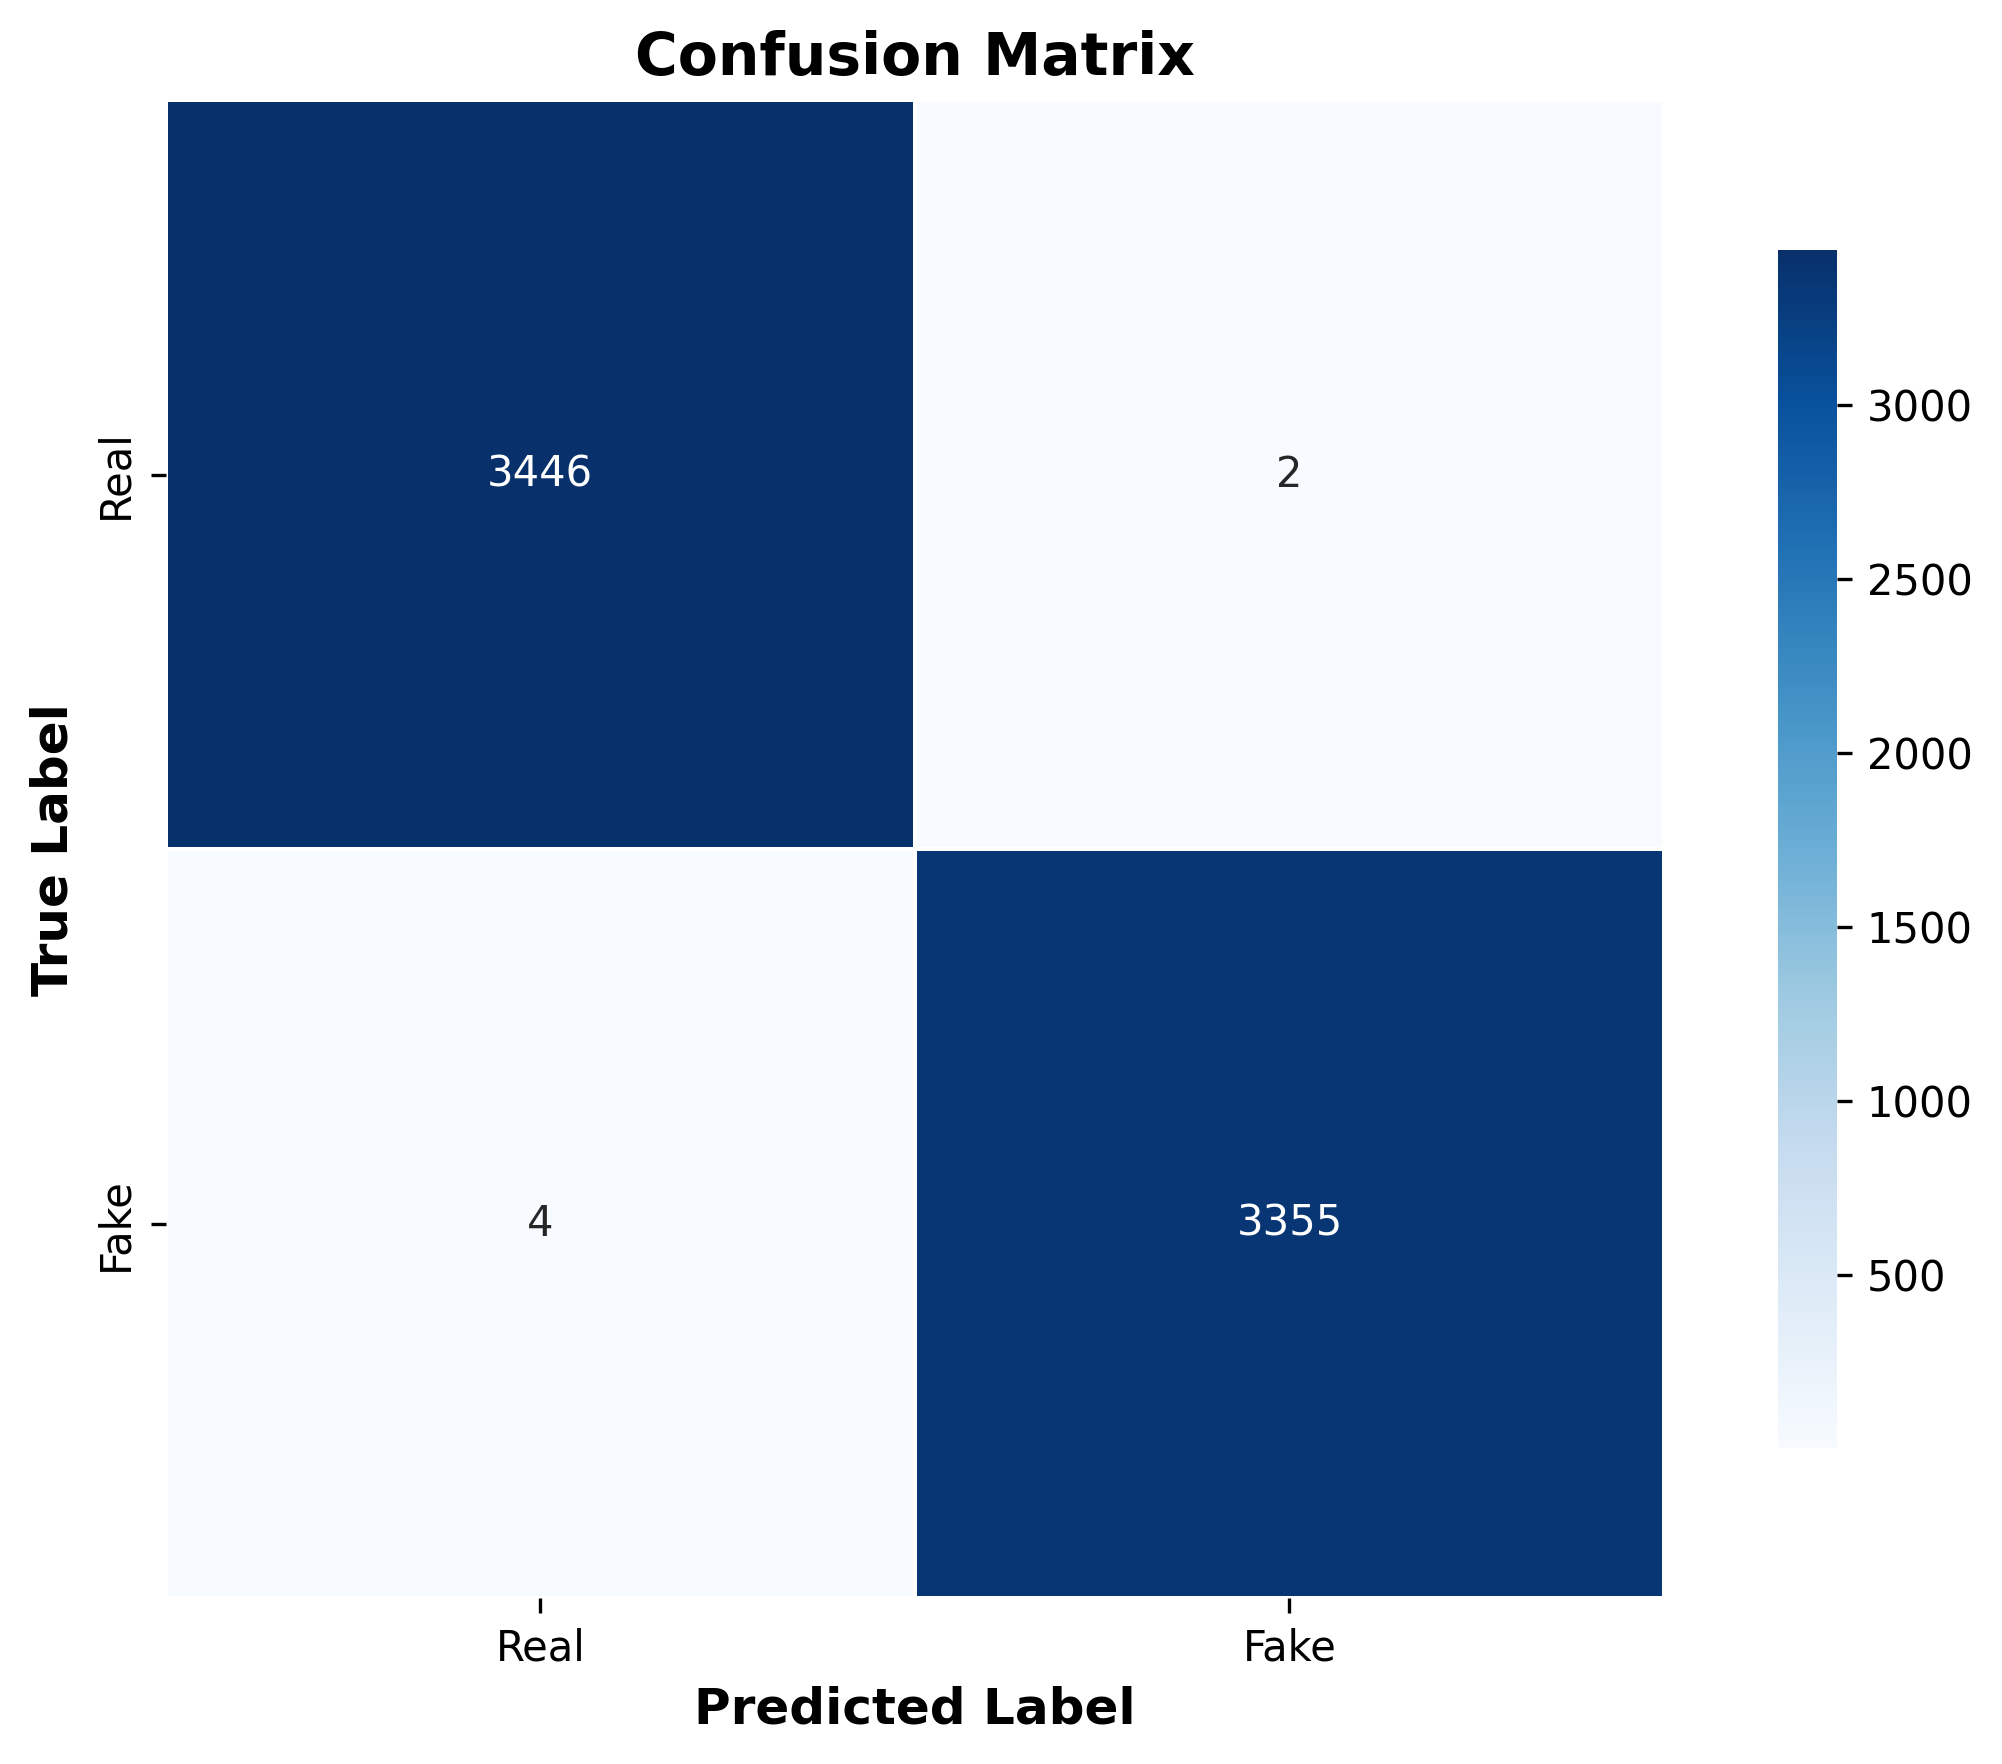


--- multimodal_pr_curve.png ---


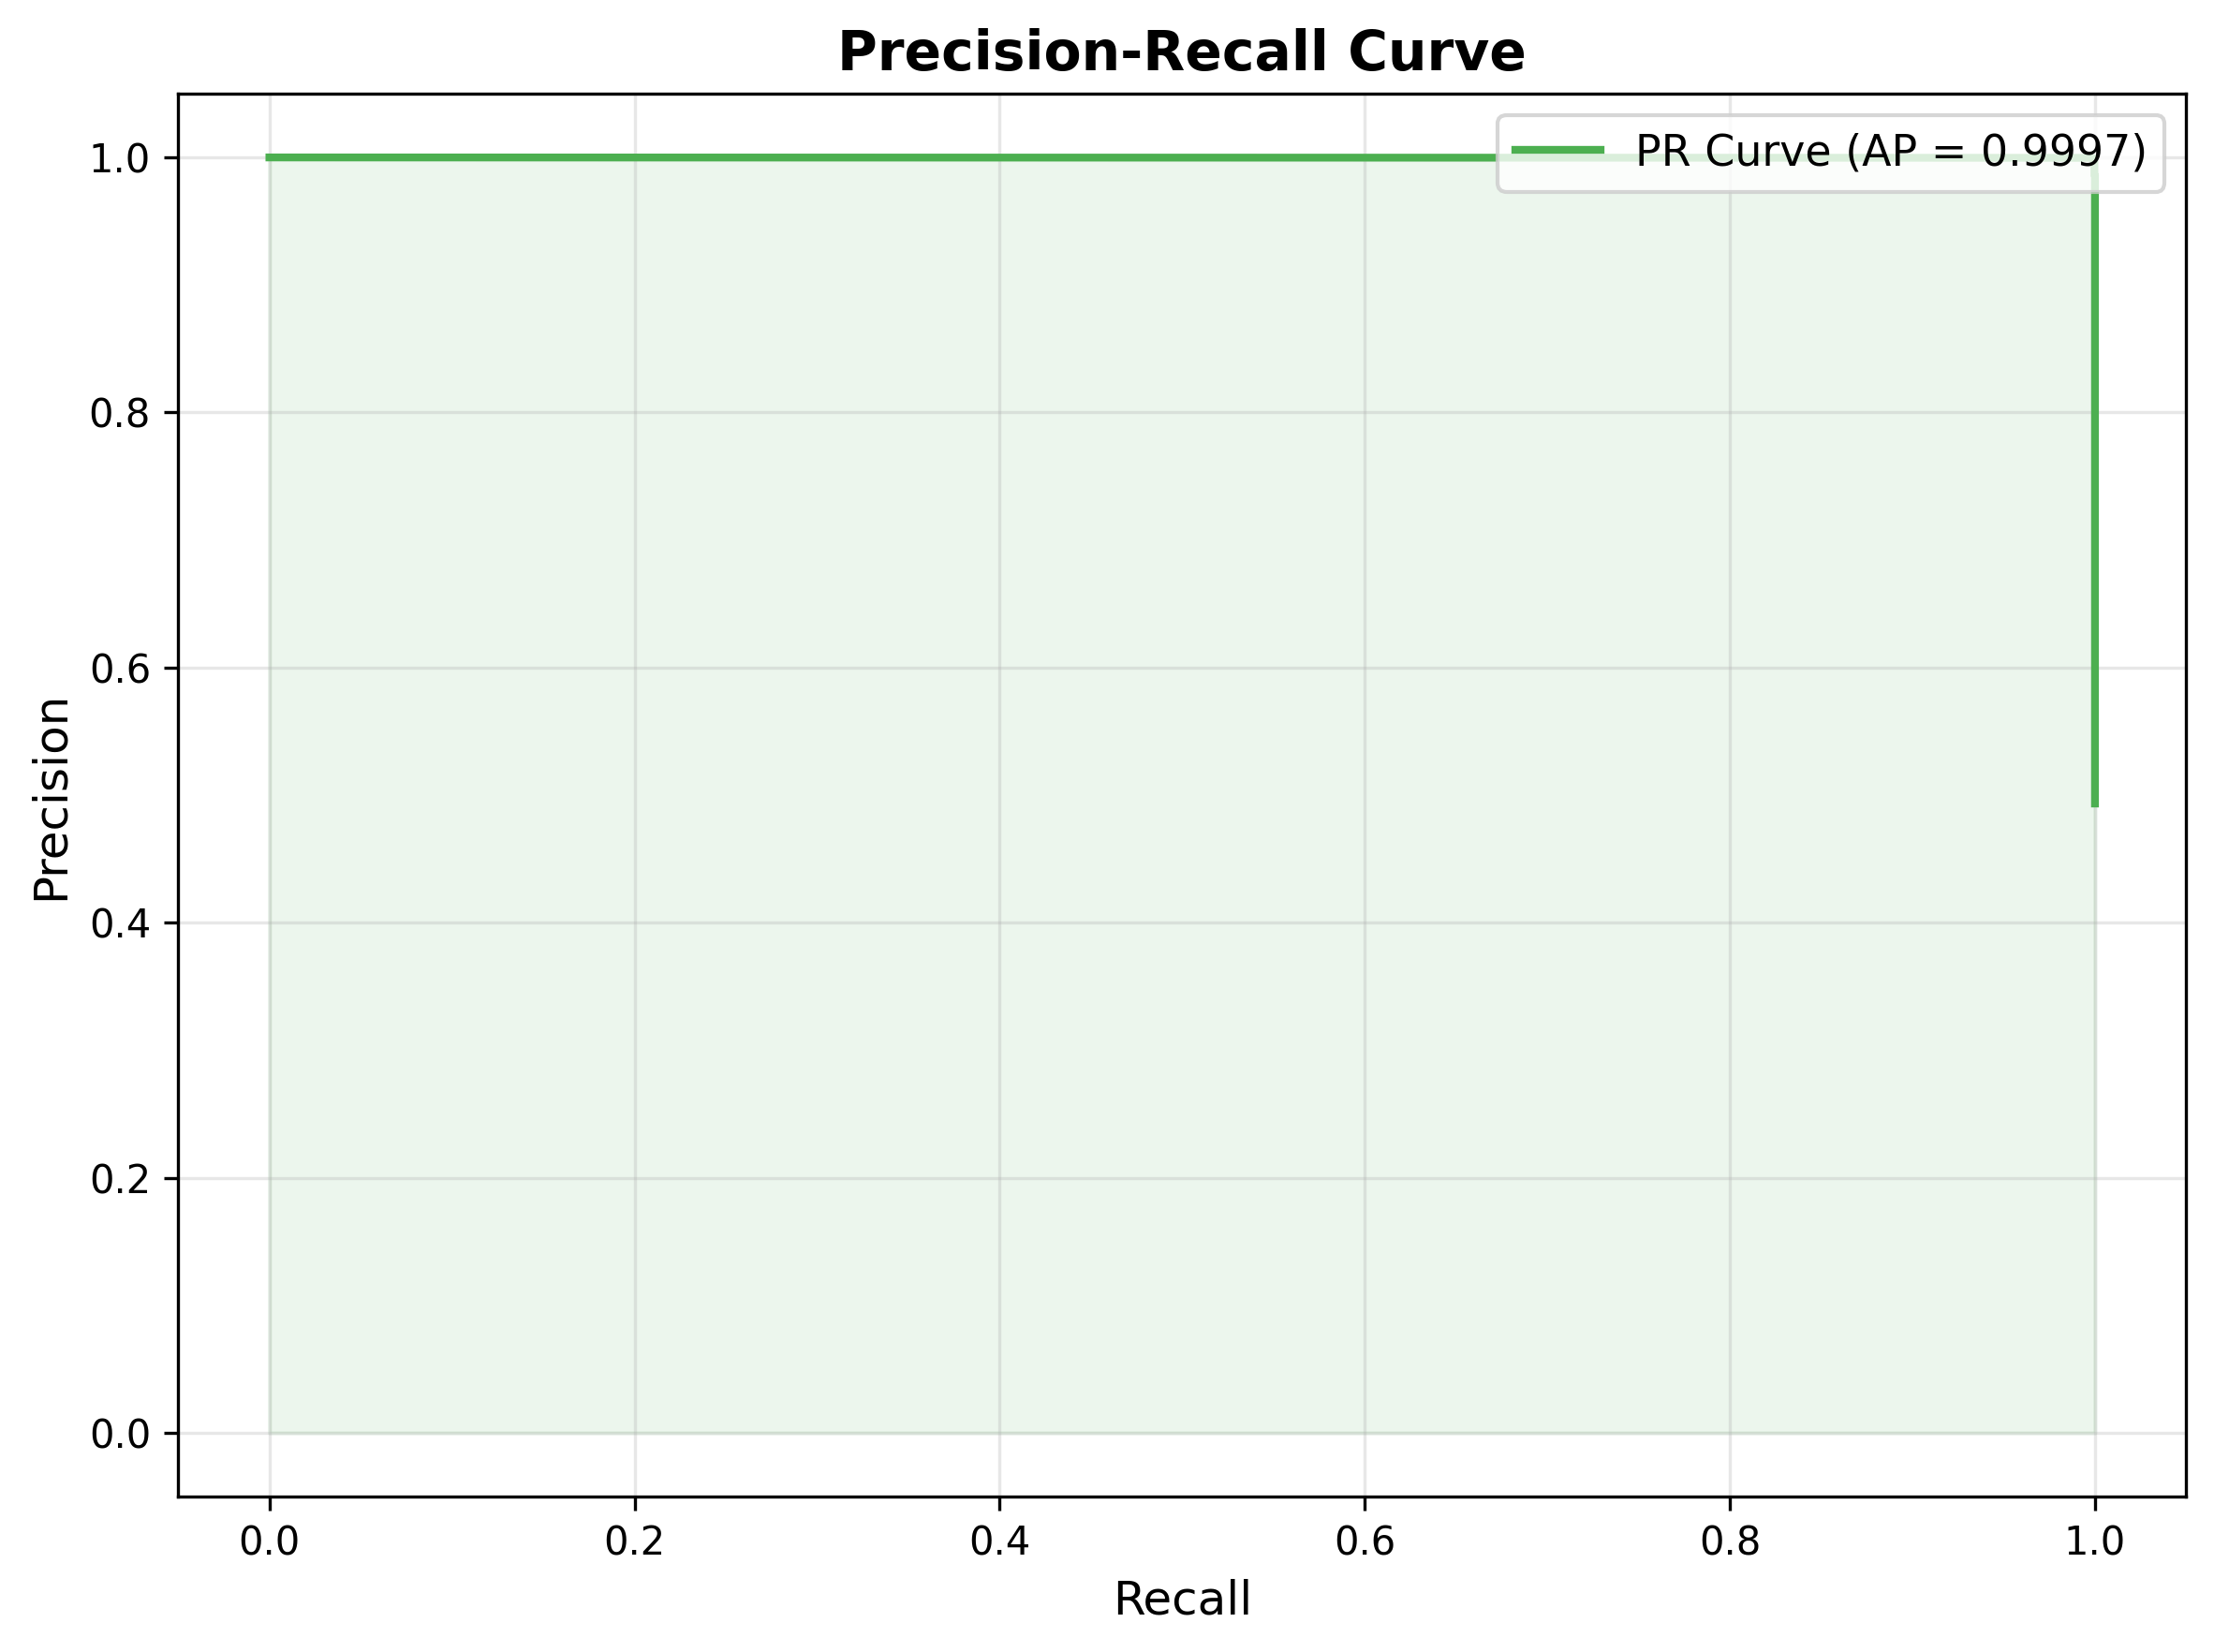


--- multimodal_roc_curve.png ---


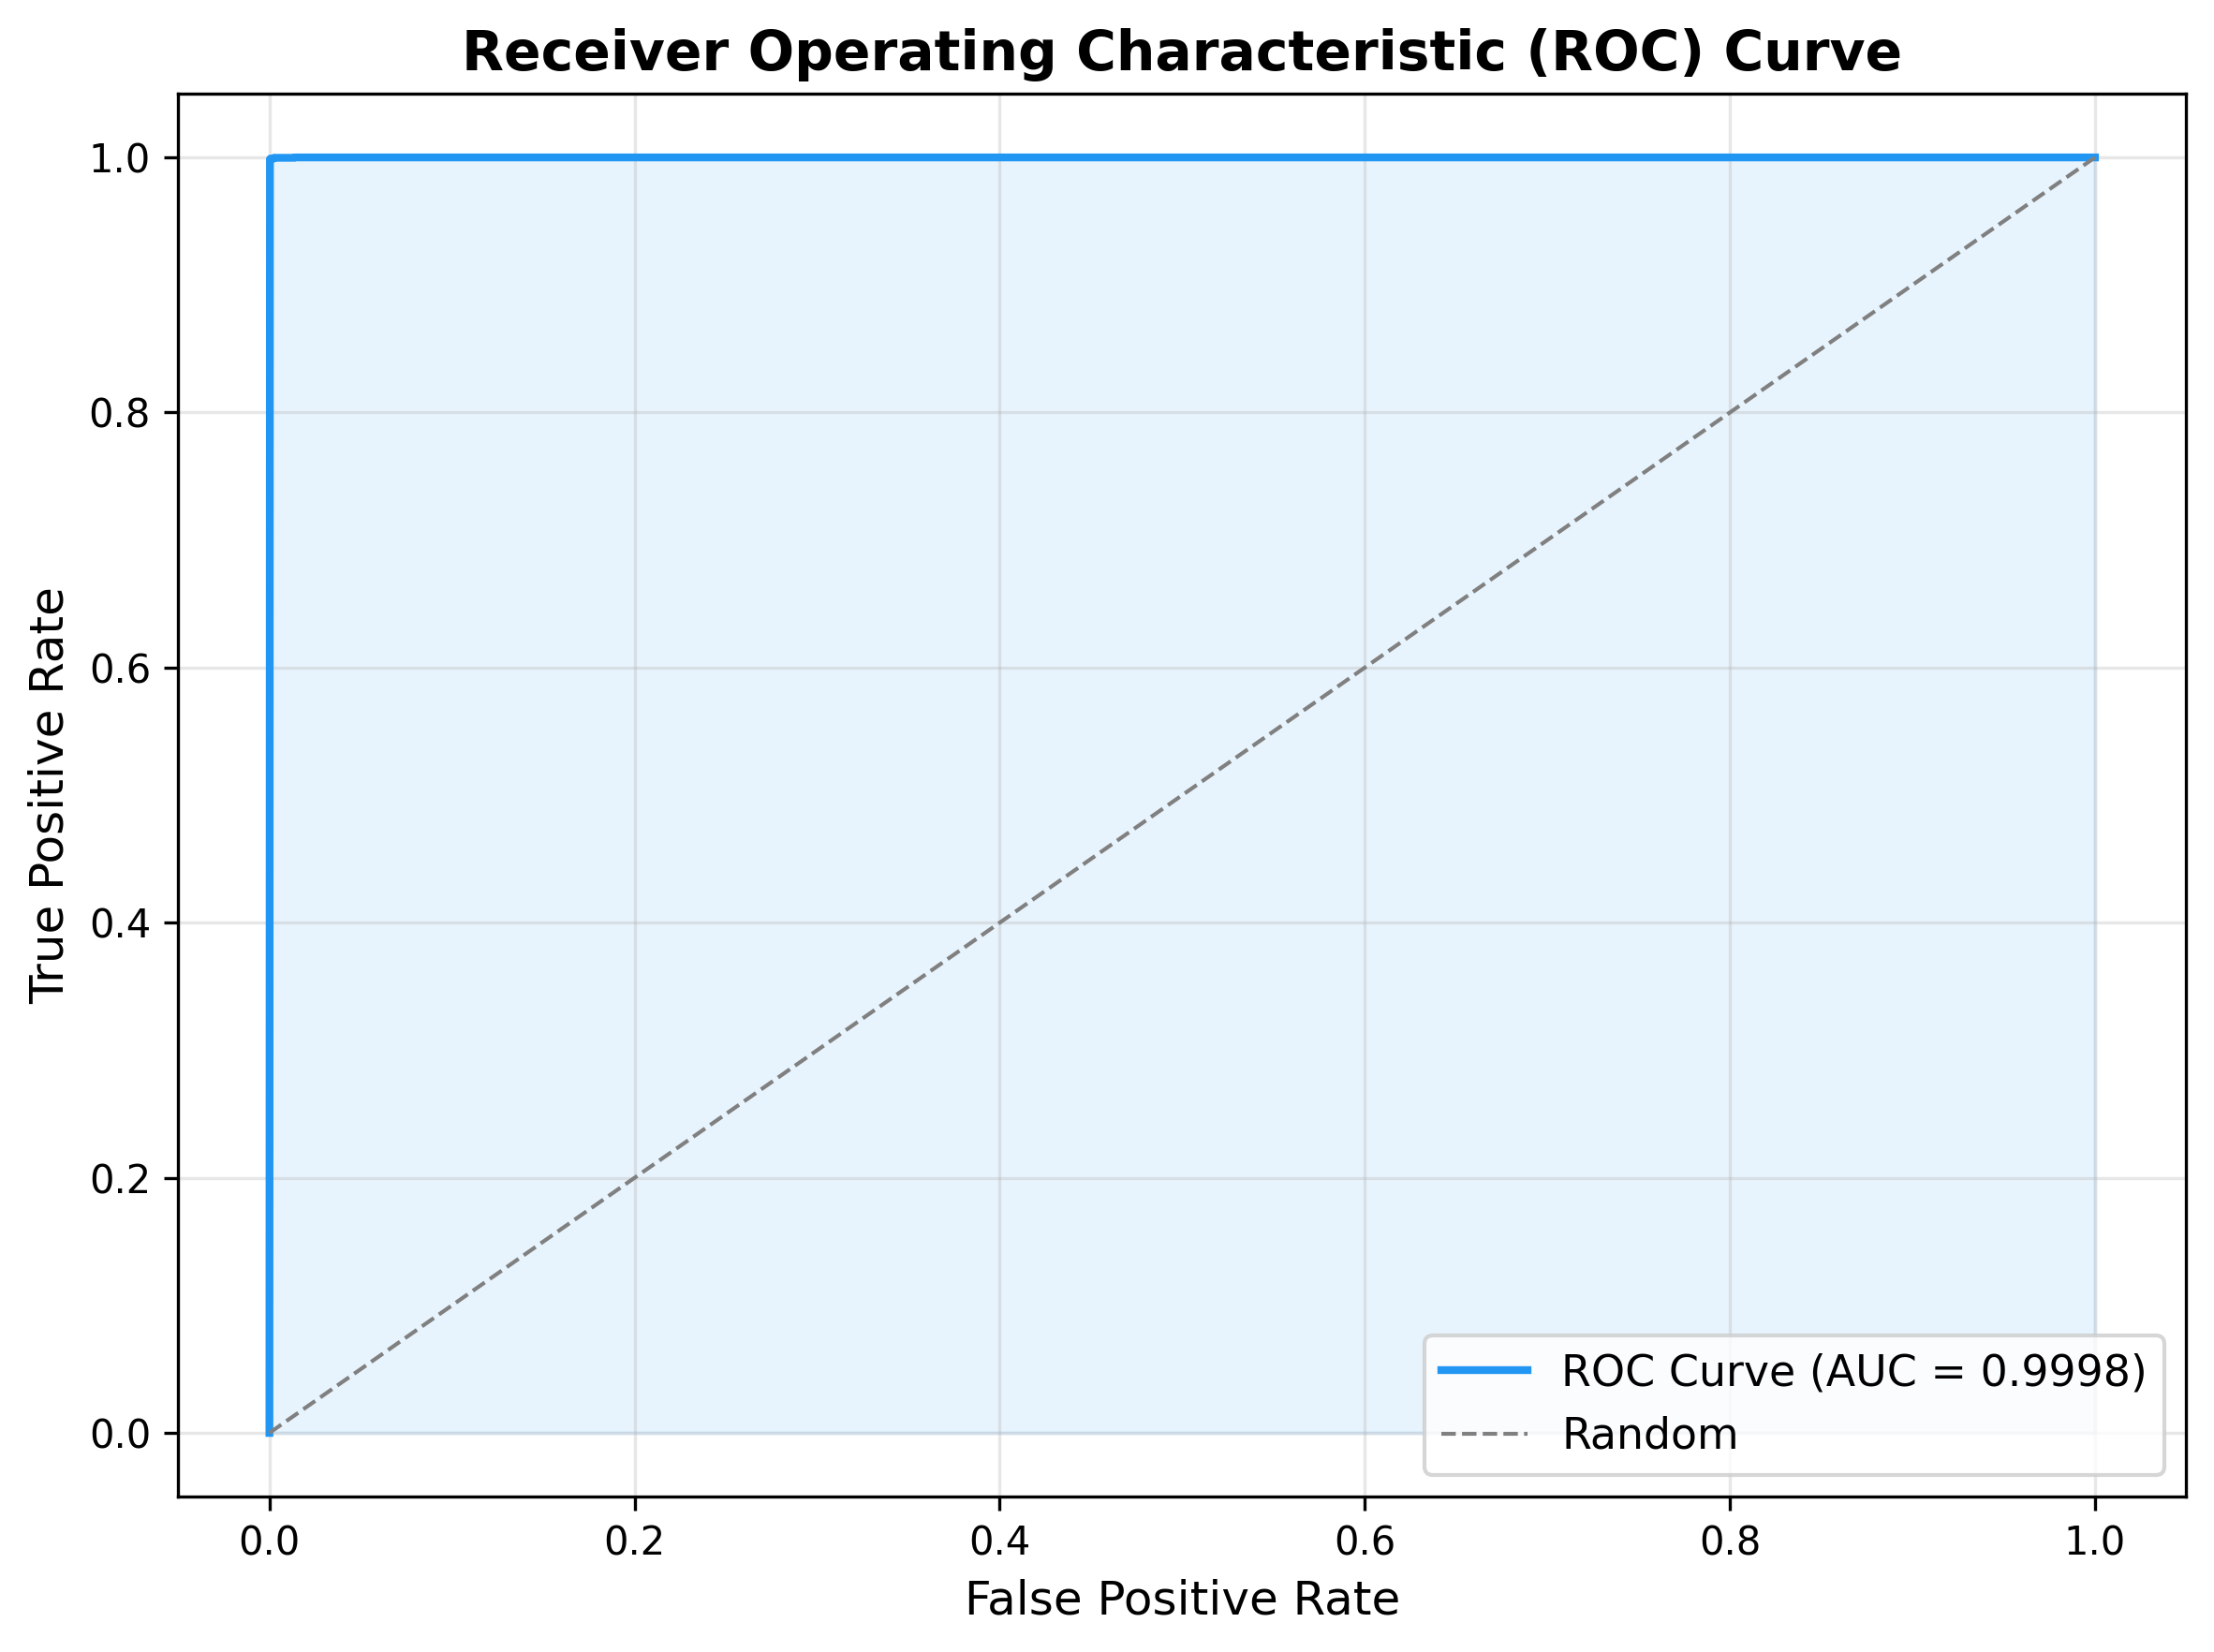

In [12]:
# ============================================================
# STEP 8: Evaluate on Test Set
# ============================================================
print('📊 Running final evaluation on test set...')
test_metrics = trainer.evaluate(
    test_loader=dataloaders['test'],
    mode=MODE,
    generate_plots=True,
)

# Show plots inline
import matplotlib.pyplot as plt
from IPython.display import display, Image as IPImage
from pathlib import Path

plots_dir = Path(config.get('logging', {}).get('log_dir', './logs')) / 'metrics'
if plots_dir.exists():
    for img in sorted(plots_dir.glob('*.png')):
        print(f'\n--- {img.name} ---')
        display(IPImage(filename=str(img)))
else:
    print('No plots directory found. Check training output.')


In [13]:
# ============================================================
# STEP 9: Plot Training History
# ============================================================
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 100

history = result['history']
epochs = [h['epoch'] for h in history]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss
axes[0].plot(epochs, [h['train_loss'] for h in history], 'b-o', label='Train', markersize=4)
axes[0].plot(epochs, [h['val_loss'] for h in history], 'r-o', label='Val', markersize=4)
axes[0].set_title('Loss', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Accuracy
axes[1].plot(epochs, [h['train_accuracy'] for h in history], 'b-o', label='Train', markersize=4)
axes[1].plot(epochs, [h['val_accuracy'] for h in history], 'r-o', label='Val', markersize=4)
axes[1].set_title('Accuracy', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(alpha=0.3)

# F1
axes[2].plot(epochs, [h['train_f1'] for h in history], 'b-o', label='Train', markersize=4)
axes[2].plot(epochs, [h['val_f1'] for h in history], 'r-o', label='Val', markersize=4)
axes[2].set_title('F1 Score', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Epoch')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.suptitle('Training History', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Print summary table
print(f"\n{'Epoch':<8} {'Train Loss':<12} {'Val Loss':<12} {'Train Acc':<12} {'Val Acc':<12} {'Train F1':<12} {'Val F1':<12}")
print('─' * 80)
for h in history:
    print(f"{h['epoch']:<8} {h['train_loss']:<12.4f} {h['val_loss']:<12.4f} {h['train_accuracy']:<12.4f} {h['val_accuracy']:<12.4f} {h['train_f1']:<12.4f} {h['val_f1']:<12.4f}")



Epoch    Train Loss   Val Loss     Train Acc    Val Acc      Train F1     Val F1      
────────────────────────────────────────────────────────────────────────────────
1        0.0968       0.0643       0.9584       0.9890       0.9584       0.9890      
2        0.0143       0.0240       0.9977       0.9966       0.9977       0.9966      
3        0.0104       0.0060       0.9984       0.9991       0.9984       0.9991      
4        0.0052       0.0039       0.9992       0.9996       0.9992       0.9996      
5        0.0041       0.0043       0.9994       0.9993       0.9994       0.9993      
6        0.0032       0.0085       0.9996       0.9991       0.9996       0.9991      
7        0.0020       0.0053       0.9997       0.9993       0.9997       0.9993      
8        0.0015       0.0044       0.9998       0.9993       0.9998       0.9993      
9        0.0007       0.0038       0.9999       0.9996       0.9999       0.9996      


In [15]:
# ============================================================
# STEP 10: GPU Memory Summary (Optional Diagnostic)
# ============================================================
if torch.cuda.is_available():
    print('=== GPU Memory Summary ===')
    print(f'  Allocated: {torch.cuda.memory_allocated() / 1e9:.2f} GB')
    print(f'  Cached:    {torch.cuda.memory_reserved() / 1e9:.2f} GB')
    print(f'  Max Alloc: {torch.cuda.max_memory_allocated() / 1e9:.2f} GB')
    print(f'  Total:     {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB')

=== GPU Memory Summary ===
  Allocated: 1.92 GB
  Cached:    4.13 GB
  Max Alloc: 4.06 GB
  Total:     15.64 GB


In [ ]:
# ============================================================
# STEP 11: Download Trained Model
# ============================================================
from google.colab import files
import shutil

# Zip checkpoints + results
ckpt_dir = os.path.join(PROJECT_DIR, 'checkpoints')
results_dir = os.path.join(PROJECT_DIR, 'results')
archive = '/content/trained_model'
dirs_to_zip = [d for d in [ckpt_dir, results_dir] if os.path.exists(d)]

if not dirs_to_zip:
    print('⚠️ No checkpoints or results found to download.')
else:
    os.makedirs('/content/export', exist_ok=True)
    for d in dirs_to_zip:
        dest = os.path.join('/content/export', os.path.basename(d))
        if os.path.exists(dest):
            shutil.rmtree(dest)
        shutil.copytree(d, dest)

    shutil.make_archive(archive, 'zip', '/content/export')
    print('📥 Downloading trained_model.zip...')
    files.download(archive + '.zip')


In [ ]:
# ============================================================
# STEP 11.5: Auto-Save Trained Model to GitHub
# ============================================================
import os, shutil, subprocess
from google.colab import userdata

# ---- CONFIGURE ----
SAVE_REPO_URL = 'https://github.com/au510621104021/FND_2027.git'
SAVE_BRANCH   = 'main'          # branch to push to (created if it doesn't exist)
COMMIT_MSG    = f'Auto-save: trained model (best F1={result["best_val_f1"]:.4f}, epoch={result["best_epoch"]})'

# ---- PAT: store in Colab Secrets as GITHUB_SAVE_TOKEN ----
# Go to 🔑 Secrets (left sidebar) → Add: GITHUB_SAVE_TOKEN = your_PAT
try:
    GITHUB_SAVE_TOKEN = userdata.get('GITHUB_SAVE_TOKEN')
except Exception:
    GITHUB_SAVE_TOKEN = os.getenv('GITHUB_SAVE_TOKEN', '').strip()

if not GITHUB_SAVE_TOKEN:
    raise ValueError(
        '❌ GitHub PAT not found!\n'
        'Add it via: 🔑 Secrets (left sidebar) → GITHUB_SAVE_TOKEN = <your PAT>\n'
        'Make sure the PAT has repo write permissions.'
    )

# ---- Dirs to save ----
ckpt_dir    = os.path.join(PROJECT_DIR, 'checkpoints')
results_dir = os.path.join(PROJECT_DIR, 'results')
logs_dir    = os.path.join(PROJECT_DIR, 'logs')

SAVE_REPO_DIR = '/content/FND_2027_save'

# ---- Clone the save repo ----
auth_url = SAVE_REPO_URL.replace('https://', f'https://{GITHUB_SAVE_TOKEN}@')

if os.path.exists(SAVE_REPO_DIR):
    shutil.rmtree(SAVE_REPO_DIR)

print(f'📥 Cloning save repo: {SAVE_REPO_URL}')
try:
    subprocess.check_call([
        'git', 'clone', '--depth', '1',
        '--branch', SAVE_BRANCH,
        auth_url, SAVE_REPO_DIR
    ])
except subprocess.CalledProcessError:
    # Branch doesn't exist yet — clone default and create branch
    print(f'   Branch "{SAVE_BRANCH}" not found — creating it...')
    subprocess.check_call(['git', 'clone', '--depth', '1', auth_url, SAVE_REPO_DIR])
    subprocess.check_call(['git', '-C', SAVE_REPO_DIR, 'checkout', '-b', SAVE_BRANCH])

# ---- Copy trained artifacts into the repo ----
for src_dir, folder_name in [
    (ckpt_dir,    'checkpoints'),
    (results_dir, 'results'),
    (logs_dir,    'logs'),
]:
    if not os.path.exists(src_dir):
        print(f'   ⚠️ Skipping {folder_name} (not found)')
        continue
    dest = os.path.join(SAVE_REPO_DIR, folder_name)
    if os.path.exists(dest):
        shutil.rmtree(dest)
    shutil.copytree(src_dir, dest)
    print(f'   ✅ Copied {folder_name}/ → repo')

# Also save the config used for this run
config_src = os.path.join(PROJECT_DIR, 'config', 'config.yaml')
if os.path.exists(config_src):
    os.makedirs(os.path.join(SAVE_REPO_DIR, 'config'), exist_ok=True)
    shutil.copy2(config_src, os.path.join(SAVE_REPO_DIR, 'config', 'config.yaml'))
    print('   ✅ Copied config/config.yaml → repo')

# ---- Git config ----
subprocess.check_call(['git', '-C', SAVE_REPO_DIR, 'config', 'user.email', 'colab-autosave@github.com'])
subprocess.check_call(['git', '-C', SAVE_REPO_DIR, 'config', 'user.name',  'Colab AutoSave'])

# Remove token from remote URL for safety
subprocess.check_call([
    'git', '-C', SAVE_REPO_DIR, 'remote', 'set-url', 'origin', SAVE_REPO_URL
])

# ---- Stage, commit, push (with token inline) ----
subprocess.check_call(['git', '-C', SAVE_REPO_DIR, 'add', '-A'])

# Check if there's anything to commit
status = subprocess.check_output(
    ['git', '-C', SAVE_REPO_DIR, 'status', '--porcelain'], text=True
).strip()

if not status:
    print('\n⚠️ No changes detected — model already up to date in GitHub.')
else:
    subprocess.check_call(['git', '-C', SAVE_REPO_DIR, 'commit', '-m', COMMIT_MSG])

    # Push using authenticated URL
    subprocess.check_call([
        'git', '-C', SAVE_REPO_DIR, 'push', auth_url,
        f'HEAD:{SAVE_BRANCH}'
    ])
    print(f'\n🎉 Model auto-saved to GitHub!')
    print(f'   Repo   : {SAVE_REPO_URL}')
    print(f'   Branch : {SAVE_BRANCH}')
    print(f'   Commit : {COMMIT_MSG}')

# ---- Cleanup cloned save repo ----
shutil.rmtree(SAVE_REPO_DIR)
print('🧹 Cleaned up local clone.')

In [ ]:
# ============================================================
# STEP 12 (Optional): Ablation Study — Compare Modalities
# ============================================================
# Uncomment to compare multimodal vs text-only vs image-only
# This demonstrates the advantage of cross-modal attention fusion

# from src.training.metrics import compare_models
# results_all = {}
# for mode in ['multimodal', 'text_only', 'image_only']:
#     print(f'\n=== {mode.upper()} ===')
#     m = trainer.evaluate(dataloaders['test'], mode=mode, generate_plots=False)
#     results_all[mode] = m
#     print(f"  Acc: {m['accuracy']:.4f}  F1: {m['f1']:.4f}")
#     if 'auc_roc' in m:
#         print(f"  AUC: {m['auc_roc']:.4f}")
# compare_models(results_all, save_dir='./results')
# print('\n✅ Ablation study complete. Check results/ for comparison plots.')


---
## 🔧 Troubleshooting

| Issue | Solution |
|---|---|
| **CUDA out of memory** | Reduce `batch_size` in Step 6 (try 4 or 2) |
| **No GPU available** | Go to Runtime → Change runtime type → GPU (T4) |
| **Clone fails** | Check repo URL, make sure it's public or set GITHUB_TOKEN |
| **Import errors** | Restart runtime: Runtime → Restart runtime |
| **Slow training** | Reduce `num_epochs` or `max_length` in Step 6 |
| **Dataset not found** | Re-upload in Step 4, check filenames match exactly |

### Architecture Reference
```
Text  → BERT(freeze=6) → Project(768→512) ─┐
                                              ├→ CrossAttn(×2, 8-head) → GatedFusion → MLP(512→256→128→2)
Image → ViT(freeze=8)  → Project(768→512) ─┘
```